# Introduction
Exploration and understanding of the different metric. I will explore the data of cox-violent-parsed-filt first.

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# data
compas = pd.read_csv("../../data/cox-violent-parsed_filt.csv")
print(compas.shape)
compas.head()

(18316, 40)


,id,name,first,last,sex,dob,age,age_cat,race,juv_fel_count,...,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,priors_count.1,event
0,1.0,miguel hernandez,miguel,hernandez,Male,18/04/1947,69,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,0,0
1,2.0,miguel hernandez,miguel,hernandez,Male,18/04/1947,69,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,0,0
2,3.0,michael ryan,michael,ryan,Male,06/02/1985,31,25 - 45,Caucasian,0,...,NaN,Risk of Recidivism,5,Medium,31/12/2014,Risk of Violence,2,Low,0,0
3,4.0,kevon dixon,kevon,dixon,Male,22/01/1982,34,25 - 45,African-American,0,...,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,27/01/2013,Risk of Violence,1,Low,0,1
4,5.0,ed philo,ed,philo,Male,14/05/1991,24,Less than 25,African-American,0,...,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,4,0


In [3]:
compas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Data columns (total 40 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       11001 non-null  float64
 1   name                     18316 non-null  object 
 2   first                    18316 non-null  object 
 3   last                     18316 non-null  object 
 4   sex                      18316 non-null  object 
 5   dob                      18316 non-null  object 
 6   age                      18316 non-null  int64  
 7   age_cat                  18316 non-null  object 
 8   race                     18316 non-null  object 
 9   juv_fel_count            18316 non-null  int64  
 10  decile_score             18316 non-null  int64  
 11  juv_misd_count           18316 non-null  int64  
 12  juv_other_count          18316 non-null  int64  
 13  priors_count             18316 non-null  int64  
 14  days_b_screening_arres

In [6]:
# Supprimer les colonnes inutiles
compas = compas.drop(
    columns=[
        "id", "name", "first", "last", "dob",
        "priors_count.1",
        "decile_score", "decile_score.1", "v_decile_score", 
        "score_text", "v_score_text",
        "type_of_assessment", "v_type_of_assessment",
        "violent_recid",
        "r_charge_degree", "r_days_from_arrest", "r_offense_date", 
        "r_charge_desc", "r_jail_in",
        "vr_charge_degree", "vr_offense_date", "vr_charge_desc",
        "c_jail_in", "c_jail_out","c_days_from_compas", "days_b_screening_arrest",
        "screening_date",
        "age_cat"
    ]
)
compas.shape

(18316, 12)

In [7]:
compas.columns

Index(['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'c_charge_degree', 'c_charge_desc',
       'is_recid', 'is_violent_recid', 'event'],
      dtype='object')

In [8]:
compas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   sex               18316 non-null  object
 1   age               18316 non-null  int64 
 2   race              18316 non-null  object
 3   juv_fel_count     18316 non-null  int64 
 4   juv_misd_count    18316 non-null  int64 
 5   juv_other_count   18316 non-null  int64 
 6   priors_count      18316 non-null  int64 
 7   c_charge_degree   17449 non-null  object
 8   c_charge_desc     17435 non-null  object
 9   is_recid          18316 non-null  int64 
 10  is_violent_recid  18316 non-null  int64 
 11  event             18316 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.7+ MB


In [10]:
compas['event'].value_counts()

event
0    17497
1      819
Name: count, dtype: int64

**sex** (object)  
- Sexe de la personne (souvent codé “Male” / “Female”).  
- Peut être utilisé pour évaluer l’équité, rarement comme variable explicative.  

**age** (int64)  
- Âge de l’individu au moment de l’évaluation COMPAS.  
- Variable prédictive importante : les plus jeunes ont souvent des risques de récidive plus élevés.  

**race** (object)  
- Groupe racial/ethnique déclaré.  
- Variable sensible : à exclure du modèle, mais à conserver pour mesurer l’équité (ex. différences de faux positifs).  

**juv_fel_count** (int64)  
- Nombre de délits criminels (felonies) commis par l’individu étant mineur.  

**juv_misd_count** (int64)  
- Nombre de délits mineurs (misdemeanors) commis en tant que mineur.  

**juv_other_count** (int64)  
- Autres délits commis étant mineur (ni felony ni misdemeanor).  

**priors_count** (int64)  
- Nombre total d’antécédents judiciaires avant l’arrestation évaluée.  
- Fortement corrélé avec le risque de récidive.  

**days_b_screening_arrest** (float64)  
- Nombre de jours entre l’arrestation et le screening COMPAS.  
- Peut indiquer un décalage temporel, mais attention aux valeurs manquantes.  

**c_days_from_compas** (float64)  
- Nombre de jours entre le screening COMPAS et l’affaire en cours (“current charge”).  
- Variable temporelle liée au dossier de l’affaire.  

**c_charge_degree** (object)  
- Gravité de l’infraction courante (ex. “M” = misdemeanor, “F” = felony).  

**c_charge_desc** (object)  
- Description textuelle de l’infraction courante (ex. “Battery”, “Drug Possession”).  
- Très riche mais difficile à utiliser directement (il faut regrouper ou encoder).  

**is_recid** (int64)  
- Indicateur binaire : 1 si la personne a récidivé (toute nature) dans les 2 ans, 0 sinon.  
- Peut être utilisé comme cible alternative si tu veux inclure récidives violentes + non violentes.  

**is_violent_recid** (int64)  
- Indicateur binaire : 1 si la personne a récidivé avec violence dans les 2 ans, 0 sinon.  
- Souvent choisi comme cible principale (y).  

**event** (int64)  
- Variable pour les modèles de survie (indique si un “événement” est survenu, ex. récidive avant censure).  
- Utile pour une approche de type Cox, mais pas pour une régression logistique simple.  


# Exploration univarié

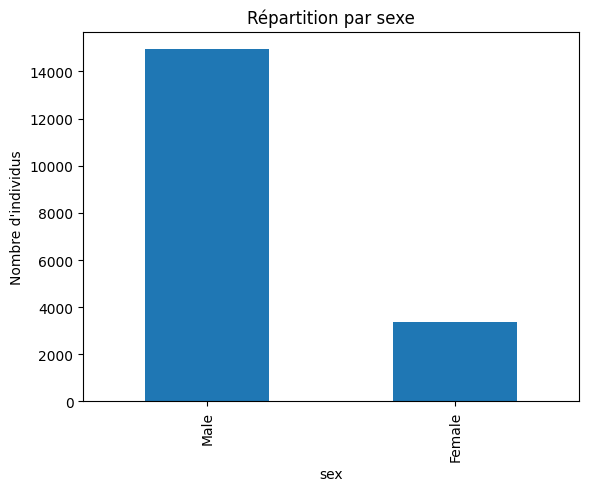

In [11]:
compas['sex'].value_counts().plot(kind='bar')
plt.title("Répartition par sexe")
plt.ylabel("Nombre d'individus")
plt.show()

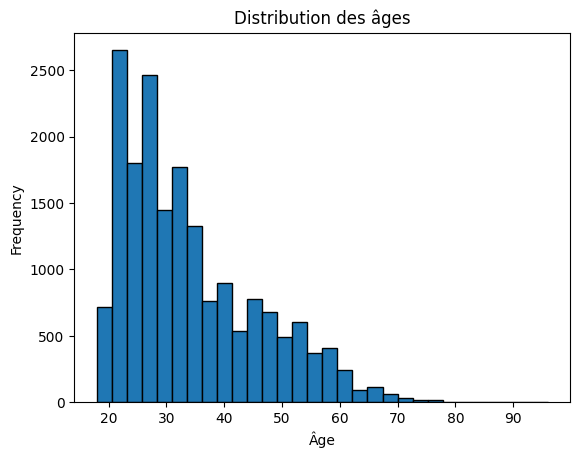

In [12]:
compas['age'].plot(kind='hist', bins=30, edgecolor='black')
plt.title("Distribution des âges")
plt.xlabel("Âge")
plt.show()


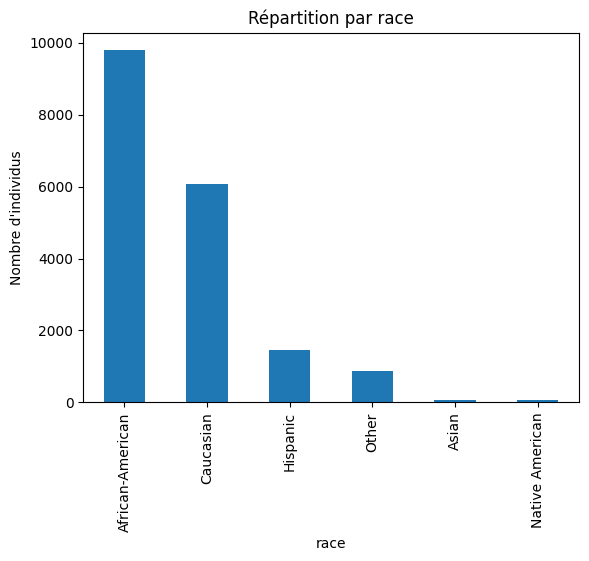

In [13]:
compas['race'].value_counts().plot(kind='bar')
plt.title("Répartition par race")
plt.ylabel("Nombre d'individus")
plt.show()


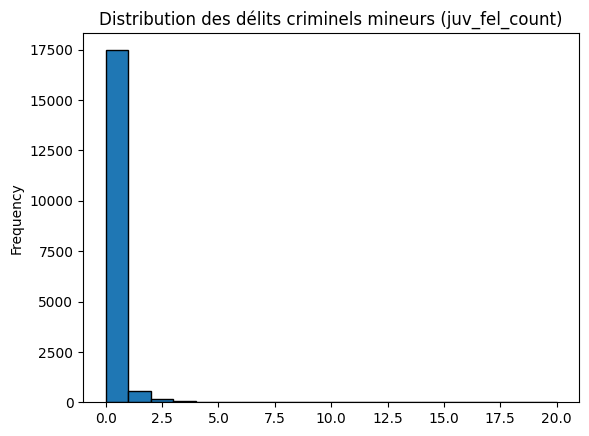

In [14]:
compas['juv_fel_count'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Distribution des délits criminels mineurs (juv_fel_count)")
plt.show()

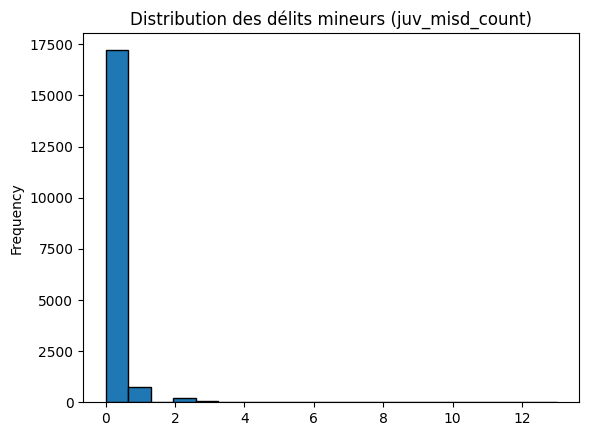

In [15]:
compas['juv_misd_count'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Distribution des délits mineurs (juv_misd_count)")
plt.show()


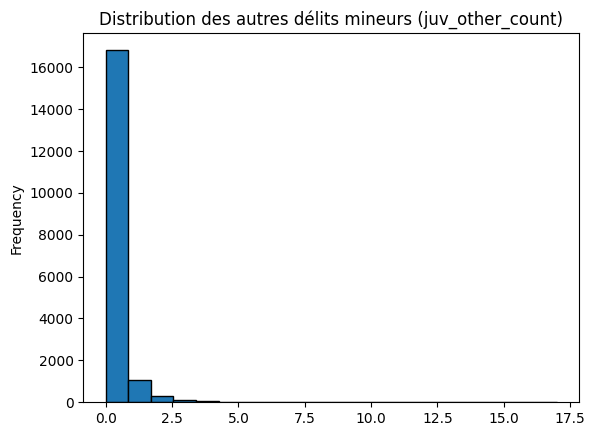

In [16]:
compas['juv_other_count'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Distribution des autres délits mineurs (juv_other_count)")
plt.show()


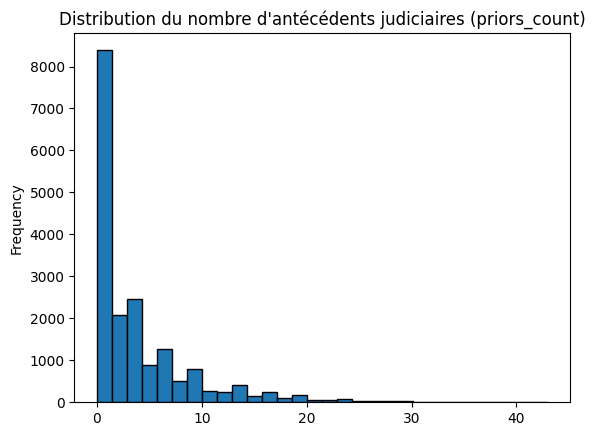

In [17]:
compas['priors_count'].plot(kind='hist', bins=30, edgecolor='black')
plt.title("Distribution du nombre d'antécédents judiciaires (priors_count)")
plt.show()


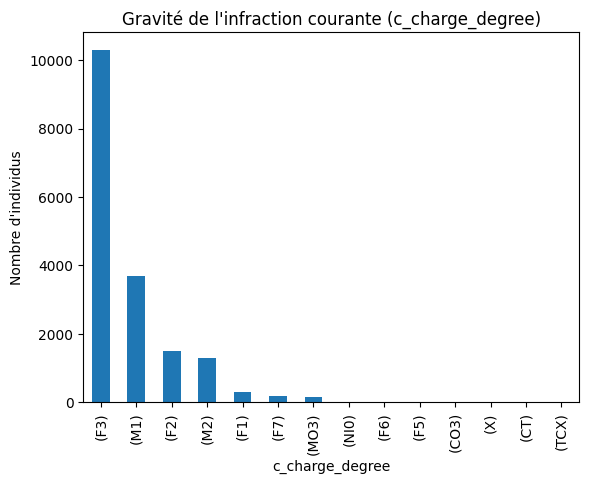

In [18]:
compas['c_charge_degree'].value_counts().plot(kind='bar')
plt.title("Gravité de l'infraction courante (c_charge_degree)")
plt.ylabel("Nombre d'individus")
plt.show()


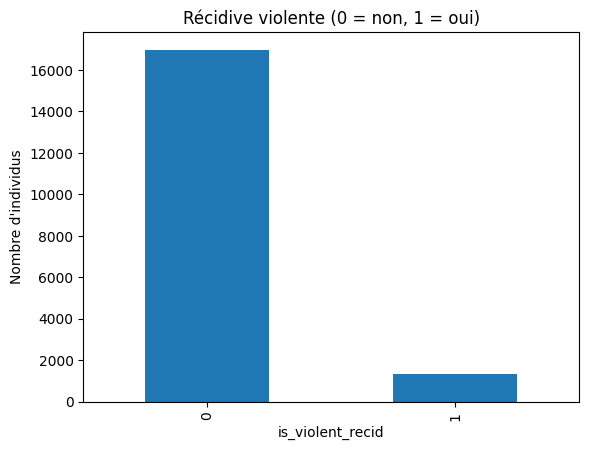

In [20]:
compas['is_violent_recid'].value_counts().plot(kind='bar')
plt.title("Récidive violente (0 = non, 1 = oui)")
plt.ylabel("Nombre d'individus")
plt.show()


# Multivarié

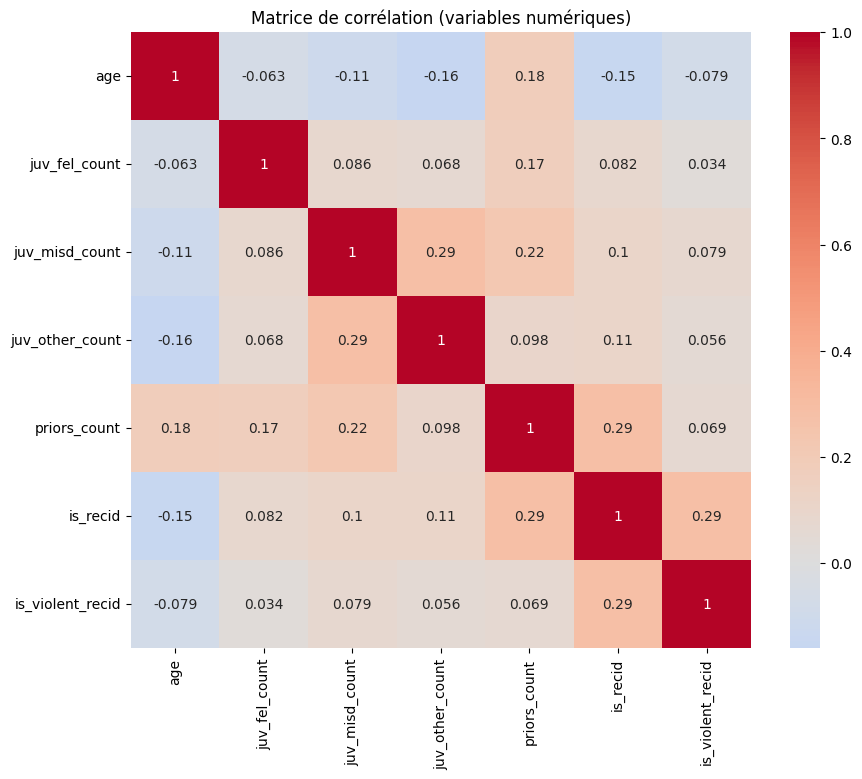

In [21]:
# Sélectionner seulement les colonnes numériques
num_cols = ["age", "juv_fel_count", "juv_misd_count", 
            "juv_other_count", "priors_count", 
            "is_recid", "is_violent_recid"]

corr = compas[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation (variables numériques)")
plt.show()


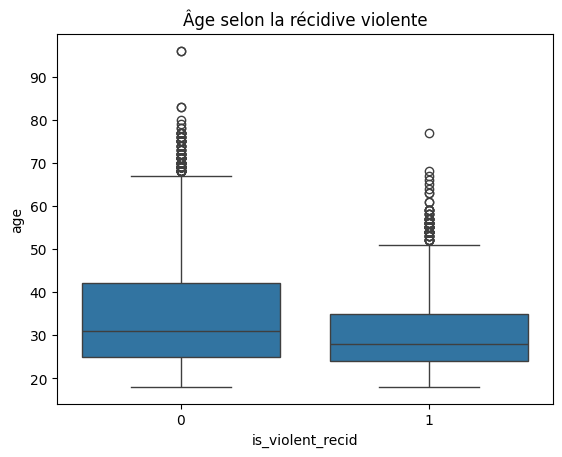

In [22]:
sns.boxplot(x="is_violent_recid", y="age", data=compas)
plt.title("Âge selon la récidive violente")
plt.show()

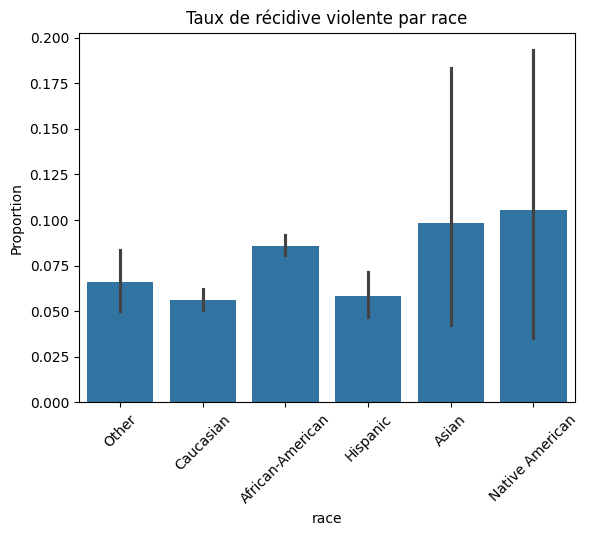

In [23]:
sns.barplot(x="race", y="is_violent_recid", data=compas, estimator=lambda x: sum(x)/len(x))
plt.title("Taux de récidive violente par race")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()


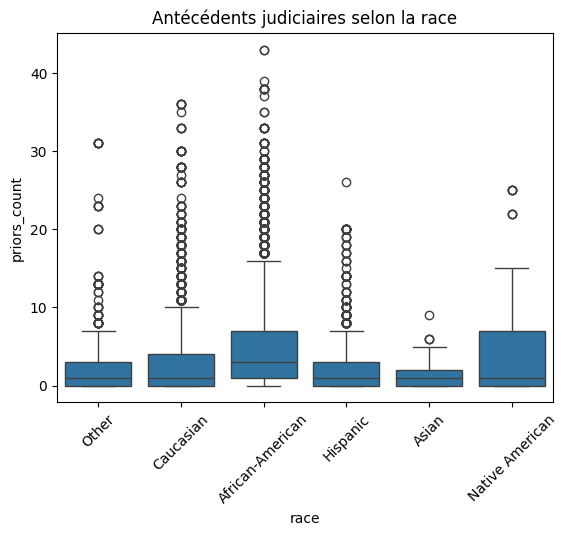

In [24]:
sns.boxplot(x="race", y="priors_count", data=compas)
plt.title("Antécédents judiciaires selon la race")
plt.xticks(rotation=45)
plt.show()

In [25]:
# Colonnes utiles
cols = [
    "sex", "age", "race", "juv_fel_count", "juv_misd_count",
    "juv_other_count", "priors_count", "c_charge_degree",
    "c_charge_desc", "is_recid", "is_violent_recid"
]
compas = compas[cols].copy()

# S'assurer que la cible est bien numérique binaire
compas["is_violent_recid"] = compas["is_violent_recid"].astype(int)

# Helper pour affichage propre (rotation labels)
def finalize(ax, title="", xlabel="", ylabel="", rotate_xticks=False):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if rotate_xticks:
        for tick in ax.get_xticklabels():
            tick.set_rotation(45)
            tick.set_ha("right")
    plt.tight_layout()
    plt.show()

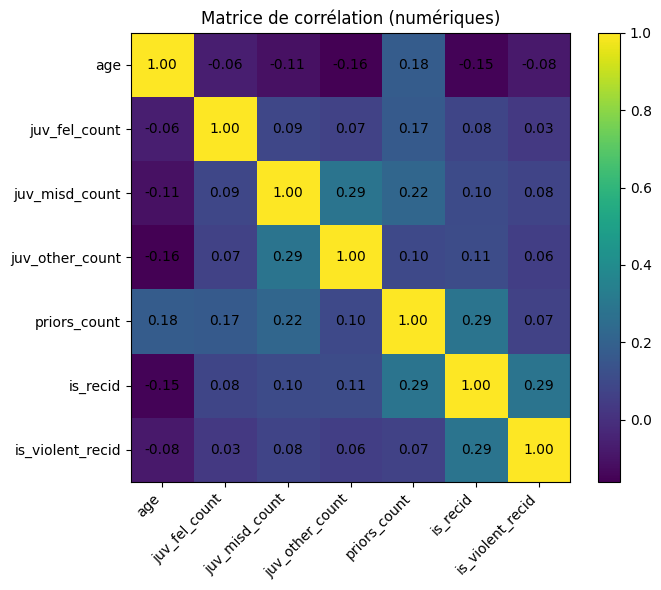

In [26]:
num_cols = ["age", "juv_fel_count", "juv_misd_count",
            "juv_other_count", "priors_count", "is_recid", "is_violent_recid"]

corr = compas[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)

# Ajouter les valeurs
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
finalize(ax, title="Matrice de corrélation (numériques)")


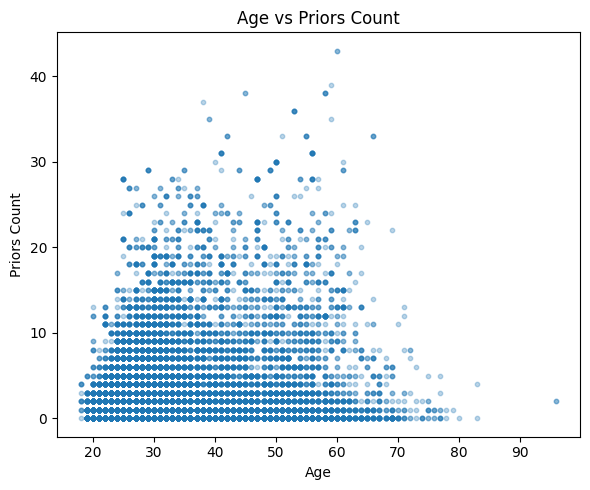

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(compas["age"], compas["priors_count"], s=10, alpha=0.3)
finalize(ax, title="Age vs Priors Count", xlabel="Age", ylabel="Priors Count")


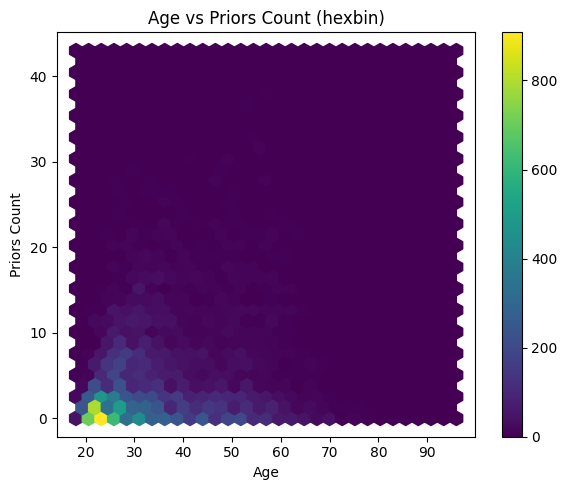

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
hb = ax.hexbin(compas["age"], compas["priors_count"], gridsize=30)
fig.colorbar(hb, ax=ax)
finalize(ax, title="Age vs Priors Count (hexbin)", xlabel="Age", ylabel="Priors Count")


/tmp/ipykernel_15830/2036674709.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=["0 (non)", "1 (oui)"], showfliers=False)


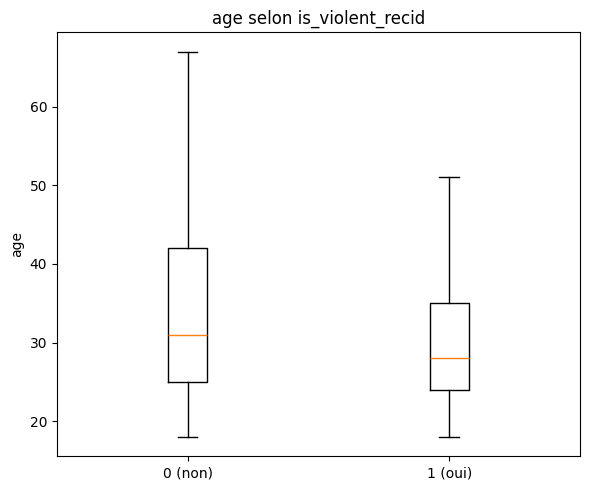

In [29]:
def boxplot_by_target(df, num_col, target_col="is_violent_recid"):
    data0 = df[df[target_col] == 0][num_col].dropna()
    data1 = df[df[target_col] == 1][num_col].dropna()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.boxplot([data0, data1], labels=["0 (non)", "1 (oui)"], showfliers=False)
    finalize(ax, title=f"{num_col} selon {target_col}", ylabel=num_col)

boxplot_by_target(compas, "age")


/tmp/ipykernel_15830/2036674709.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=["0 (non)", "1 (oui)"], showfliers=False)


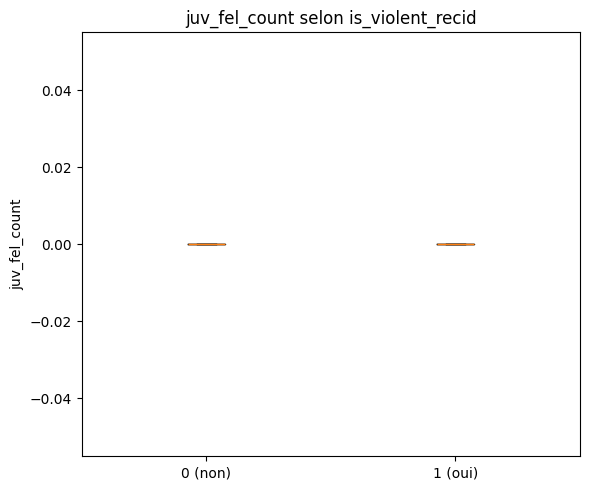

/tmp/ipykernel_15830/2036674709.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=["0 (non)", "1 (oui)"], showfliers=False)


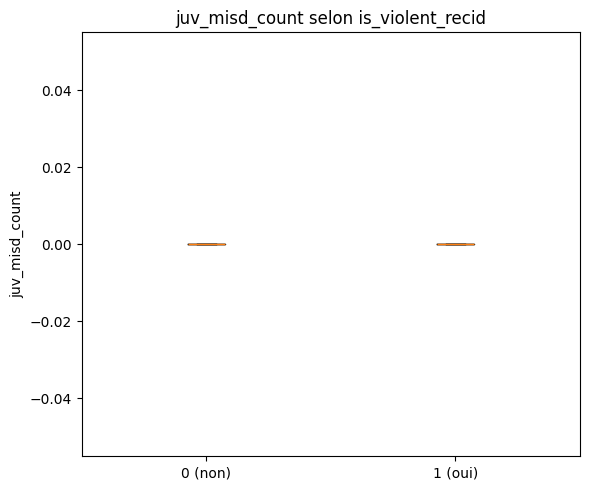

/tmp/ipykernel_15830/2036674709.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=["0 (non)", "1 (oui)"], showfliers=False)


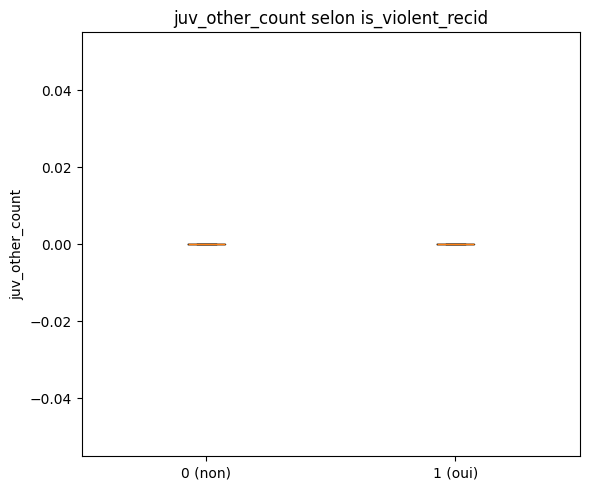

/tmp/ipykernel_15830/2036674709.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=["0 (non)", "1 (oui)"], showfliers=False)


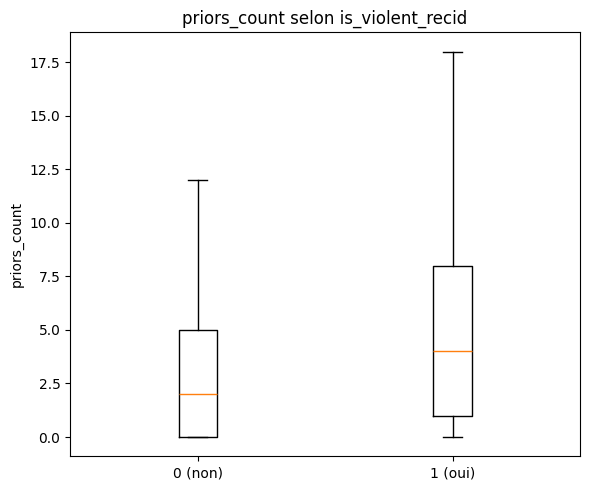

In [30]:
for col in ["juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count"]:
    boxplot_by_target(compas, col)

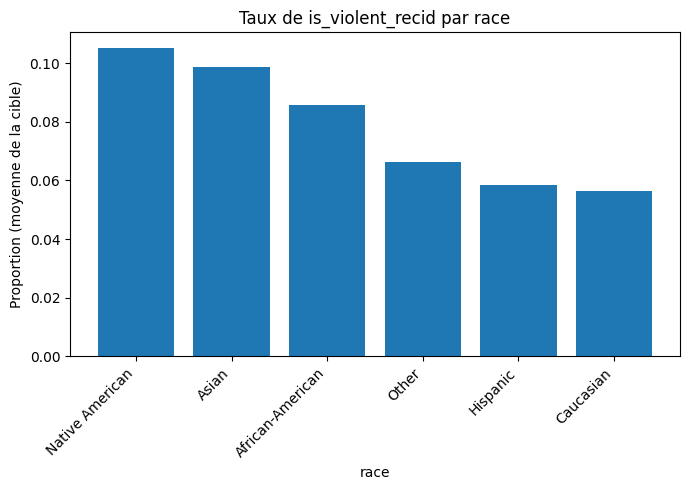

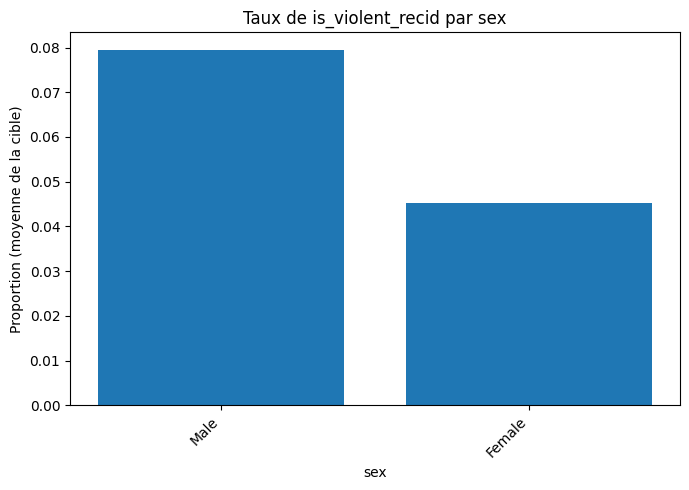

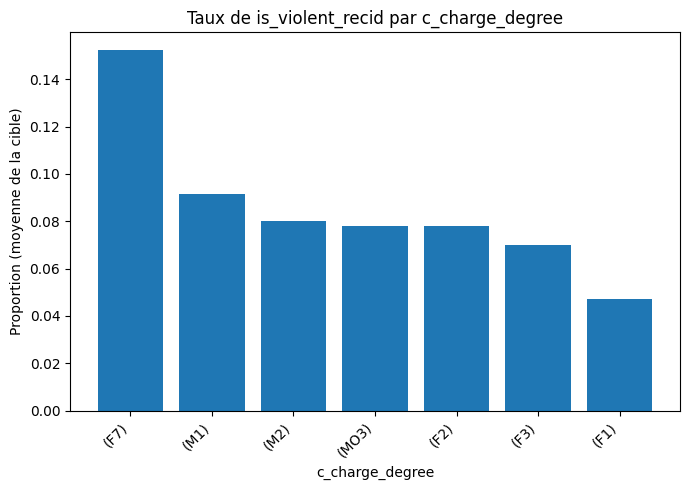

In [31]:
def plot_rate_by_category(df, cat_col, target_col="is_violent_recid", min_count=20):
    # calcul de la proportion de 1 par catégorie (en filtrant les petits effectifs)
    g = df.groupby(cat_col)[target_col].agg(['mean', 'count']).sort_values('mean', ascending=False)
    g = g[g['count'] >= min_count]  # optionnel
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(g.index.astype(str), g['mean'].values)
    finalize(ax, title=f"Taux de {target_col} par {cat_col}",
             xlabel=cat_col, ylabel="Proportion (moyenne de la cible)", rotate_xticks=True)

plot_rate_by_category(compas, "race")
plot_rate_by_category(compas, "sex")
plot_rate_by_category(compas, "c_charge_degree")


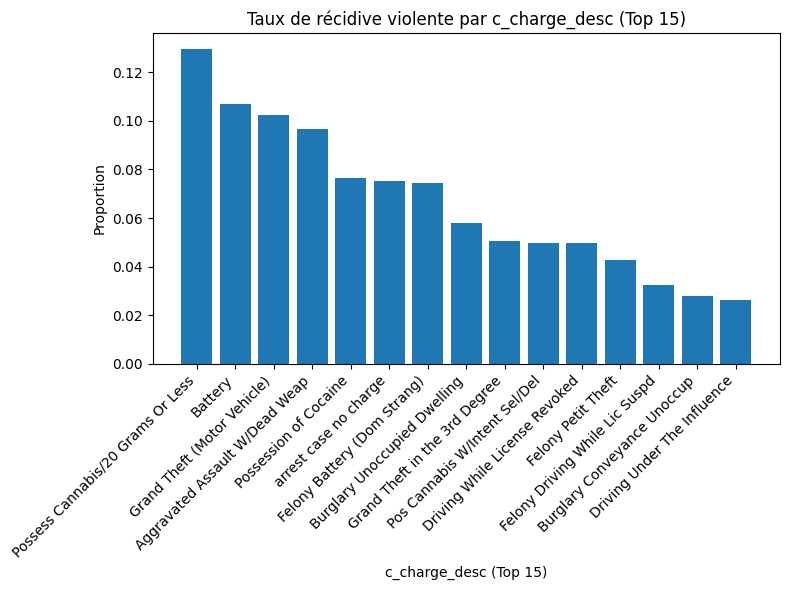

In [32]:
# Top 15 catégories par effectif, puis leur taux de récidive violente
N = 15
top_desc = compas["c_charge_desc"].value_counts().head(N).index
df_top = compas[compas["c_charge_desc"].isin(top_desc)]
g = df_top.groupby("c_charge_desc")["is_violent_recid"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(g.index.astype(str), g.values)
finalize(ax, title="Taux de récidive violente par c_charge_desc (Top 15)",
         xlabel="c_charge_desc (Top 15)", ylabel="Proportion", rotate_xticks=True)


/tmp/ipykernel_15830/1030805607.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


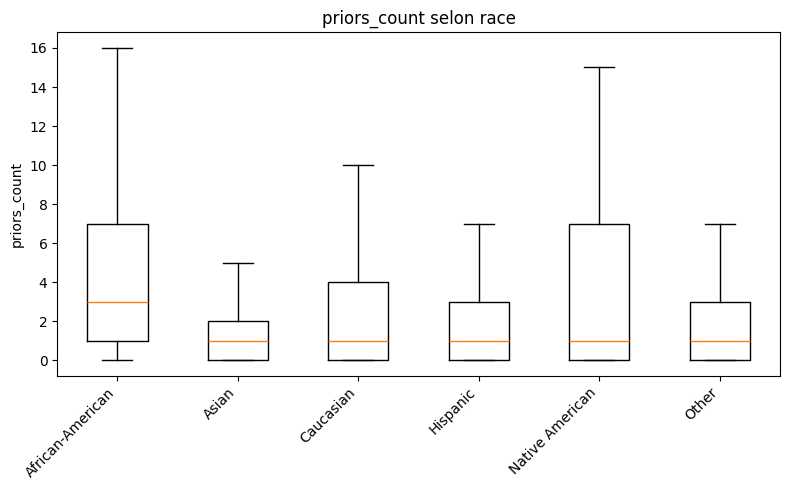

In [33]:
def boxplot_num_by_category(df, num_col, cat_col):
    groups = [v.dropna() for k, v in df.groupby(cat_col)[num_col]]
    labels = [str(k) for k, _ in df.groupby(cat_col)]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(groups, labels=labels, showfliers=False)
    finalize(ax, title=f"{num_col} selon {cat_col}", ylabel=num_col, rotate_xticks=True)

boxplot_num_by_category(compas, "priors_count", "race")


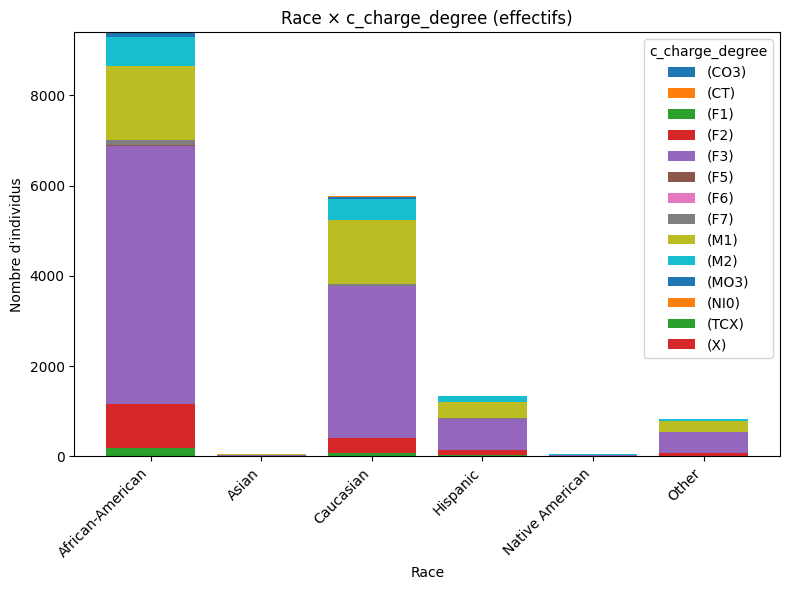

In [36]:
ct = pd.crosstab(compas["race"], compas["c_charge_degree"])

fig, ax = plt.subplots(figsize=(8, 6))
bottom = np.zeros(len(ct))
for col in ct.columns:
    ax.bar(ct.index.astype(str), ct[col].values, bottom=bottom, label=str(col))
    bottom += ct[col].values

ax.legend(title="c_charge_degree")
finalize(ax, title="Race × c_charge_degree (effectifs)", xlabel="Race", ylabel="Nombre d'individus", rotate_xticks=True)


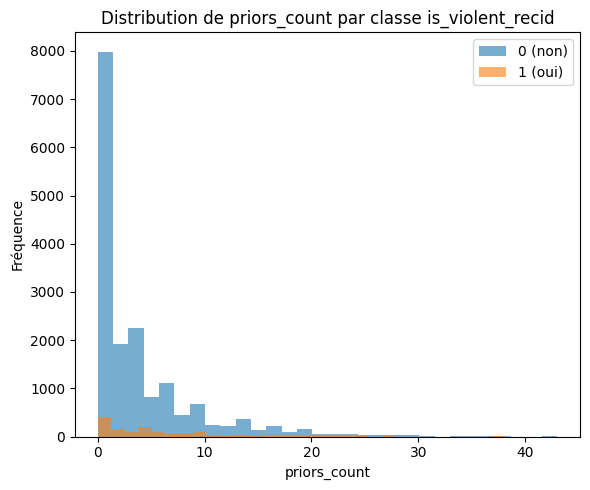

In [37]:
def hist_by_class(df, num_col, target_col="is_violent_recid", bins=30):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.hist(df[df[target_col]==0][num_col].dropna(), bins=bins, alpha=0.6, label="0 (non)")
    ax.hist(df[df[target_col]==1][num_col].dropna(), bins=bins, alpha=0.6, label="1 (oui)")
    ax.legend()
    finalize(ax, title=f"Distribution de {num_col} par classe {target_col}", xlabel=num_col, ylabel="Fréquence")

hist_by_class(compas, "priors_count")


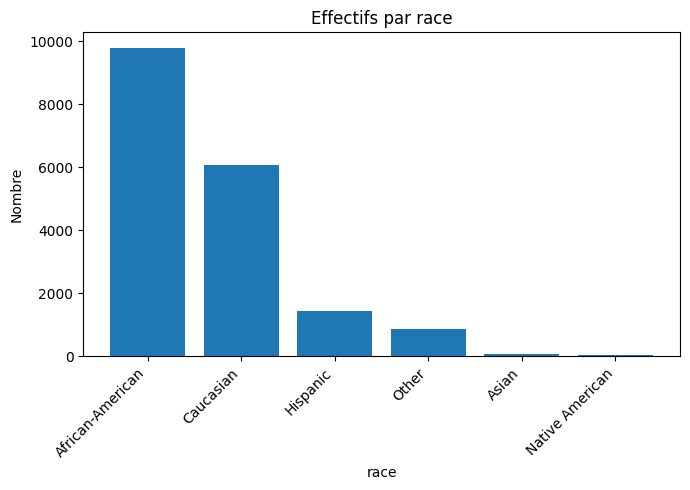

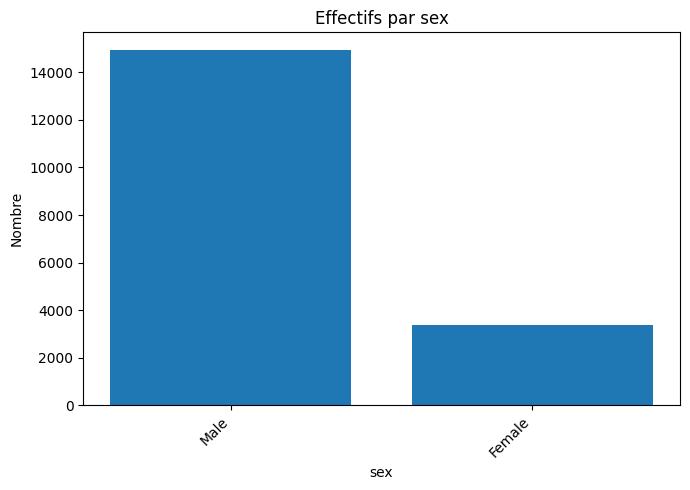

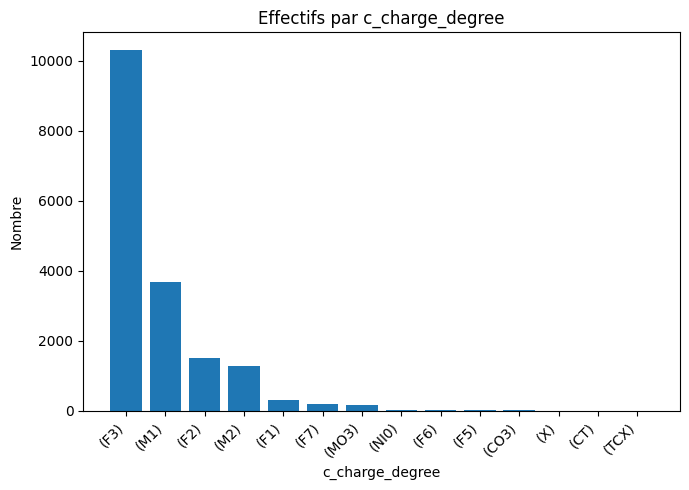

In [38]:
def bar_count(df, cat_col):
    vc = df[cat_col].value_counts()
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(vc.index.astype(str), vc.values)
    finalize(ax, title=f"Effectifs par {cat_col}", xlabel=cat_col, ylabel="Nombre", rotate_xticks=True)

bar_count(compas, "race")
bar_count(compas, "sex")
bar_count(compas, "c_charge_degree")


In [39]:
# Save the cleaned dataset as CSV
output_path = "../../data/clean/compas_cleaned.csv"
compas.to_csv(output_path, index=False)

print(f"File saved as: {output_path}")


File saved as: ../../data/clean/compas_cleaned.csv
